# Лабораторная работа 3. TF-IDF и классификация текстов

#### Работу выполнил: Самойло Александр, студент группы ФИб-4

**Задание 1.** Изучите работу с классом `TfIdfVectorizer` библиотеки `sklearn` - справка по классу [ссылка](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)

In [4]:
import pymorphy2
try:
    morph = pymorphy2.MorphAnalyzer()
    print("Pymorphy работает!")
except Exception as e:
    print(f"Ошибка в Pymorphy: {e}")

from natasha import MorphVocab
try:
    mv = MorphVocab()
    print("Natasha MorphVocab работает!")
except Exception as e:
    print(f"Ошибка в Natasha: {e}")

Pymorphy работает!
Natasha MorphVocab работает!


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from natasha import(
    Segmenter,
    MorphVocab,
    NewsEmbedding,
    NewsMorphTagger,
    NewsSyntaxParser,
    Doc,
)

segmenter = Segmenter()
morph_vocab = MorphVocab()
emb = NewsEmbedding()
morph_tagger = NewsMorphTagger(emb)


def lemmatize_text(text):
    doc = Doc(text)
    doc.segment(segmenter)
    doc.tag_morph(morph_tagger)
    for token in doc.tokens:
        token.lemmatize(morph_vocab)
    return [_.lemma for _ in doc.tokens if _.pos != 'PUNCT']

corpus = [
    'Футболист забил решающий гол в финале лиги.',
    'Тренер обсуждает тактику и замены на матч.',
    'Вратарь совершил невероятный сейв в конце матча.',
    'Болельщики поют гимн и поддерживают футбольный клуб.'
]

lemmatize_corpus = [' '.join(lemmatize_text(text)) for text in corpus]

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(lemmatize_corpus)
names_out = vectorizer.get_feature_names_out()
print(X.shape)
print(X.toarray())
print('Слова в начальной форме:')
print(names_out)


(4, 23)
[[0.         0.         0.         0.40824829 0.40824829 0.
  0.         0.         0.40824829 0.         0.         0.
  0.         0.         0.         0.40824829 0.         0.
  0.         0.         0.40824829 0.40824829 0.        ]
 [0.         0.         0.         0.         0.         0.42176478
  0.         0.         0.         0.3325242  0.42176478 0.
  0.42176478 0.         0.         0.         0.         0.
  0.42176478 0.42176478 0.         0.         0.        ]
 [0.         0.42176478 0.         0.         0.         0.
  0.         0.42176478 0.         0.3325242  0.         0.42176478
  0.         0.         0.         0.         0.42176478 0.42176478
  0.         0.         0.         0.         0.        ]
 [0.40824829 0.         0.40824829 0.         0.         0.
  0.40824829 0.         0.         0.         0.         0.
  0.         0.40824829 0.40824829 0.         0.         0.
  0.         0.         0.         0.         0.40824829]]
Слова в начальн

**Задание 2.** Сделайте классификацию новостных текстов из предыдущей лабораторной работы.\
Векторизация `tf-idf` имеет два этапа:
- построение словаря,
- построение векторов текстов.

Поэтому исходный датасет надо разделить на две части. **Первая** часть будет использоваться для формирования словаря, а **вторая** часть для обучения и тестирования модели классификации. Это делается, чтобы словарь был независим от обучения.

Основные действия:
- предобработка (токенизация, удаление пунктуации, лематизация),
- разбиение датасета на две части в отношении 1:1 (первую используйте для построения словаря, а вторую часть - для обучения и тестирования модели классификации),
- построение словаря **заданного размера `k`** для `tf-idf` векторизации по первой части датасета,
- векторизация текстов второй части выборки по получившемуся словарю,
- разбиение второй части датасета на две части в отношении 4:1 (обучающая выборка и валидационная выборка),
- обучение линейной модели **SVM** на обучающей выборке,
- оценивание качества классификации обученной модели на валидационной выборке,
- обучение модели **логистической регрессии** на обучающей выборке,
- оценивание качества классификации обученной модели на валидационной выборке.

In [6]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

file_path = "data\\news_lemmatized.csv"
if os.path.exists(file_path):
    print(f"Файл {file_path} найден.")
    df = pd.read_csv(file_path)
else:
    print(f"Файл {file_path} не найден.")

print(f"Количество строк до удаления пропусков: {len(df)}")
print(df['processed_text'].isna().sum())# количество пропусков в колонке с текстом
if df['processed_text'].isna().sum() > 0:
    print(df[df['processed_text'].isna()]) #посмотреть на пустые строки

df = df.dropna(subset=['processed_text'])
df = df[df['processed_text'].str.strip() != ''] # удаление строк, которые содержат только пробелы
print(f"Количество строк после удаления пропусков: {len(df)}")

Файл data\news_lemmatized.csv найден.
Количество строк до удаления пропусков: 4000
0
Количество строк после удаления пропусков: 4000


In [7]:
train_df, test_df = train_test_split(df,
                                    test_size=0.5, 
                                    random_state=42, 
                                    stratify=df['topic'])

print(f"Количество строк в обучающей выборке для словаря: {len(train_df)}")
print(f"Количество строк в тестовой выборке для классификации: {len(test_df)}")

# построение словаря заданного размера k на первой части
k = 5000 
vectorizer = TfidfVectorizer(max_features=k)

# Обучение векторизатора ТОЛЬКО на тренировочной модели, чтобы собрать словарь
vectorizer.fit(train_df['processed_text'])
#используя тексты из обучающего набора
X_model_total = vectorizer.transform(test_df['processed_text'])
y_model_total = test_df['topic']

X_train, X_val, y_train, y_val = train_test_split( #разбивка на обучающую и валидационную выборки для модели
    X_model_total, 
    y_model_total, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_model_total # баланс тем
)

print(f"Словарь из {k} слов построен.")
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер валидационной выборки: {X_val.shape}")

Количество строк в обучающей выборке для словаря: 2000
Количество строк в тестовой выборке для классификации: 2000
Словарь из 5000 слов построен.
Размер обучающей выборки: (1600, 5000)
Размер валидационной выборки: (400, 5000)


In [ ]:
'''
    Метод опорных векторов: для проведения в пространстве слов(векторов)
    границы(гиперплоскость) между классами, чтобы расстояние от границы
    до ближайших точек каждого класса было максимально большим.

    Логистическая регрессия: для вычисления вероятности того, что данный 
    текст относится к конкретной теме.
'''

'\n    Метод опорных векторов: для провдеения в пространстве слов(векторов)\n    границы(гиперплоскость) между классами, чтобы расстояние от границы\n    до ближайших точек каждого класса было максимально большим.\n\n    Логистическая регрессия: для вычисления вероятности того, что данный \n    текст относится к конкретной теме.\n'

In [8]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

print('Модель SVM:')
svm_model = LinearSVC(random_state=42 ,max_iter=10000)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_val)

print(classification_report(y_val, y_pred_svm))

print('Модель Logistic Regression:')
lr_model = LogisticRegression(random_state=42, max_iter=10000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_val)

print(classification_report(y_val, y_pred_lr))

Модель SVM:
              precision    recall  f1-score   support

    Культура       0.99      1.00      1.00       200
   Экономика       1.00      0.99      0.99       200

    accuracy                           0.99       400
   macro avg       1.00      0.99      0.99       400
weighted avg       1.00      0.99      0.99       400

Модель Logistic Regression:
              precision    recall  f1-score   support

    Культура       0.99      0.99      0.99       200
   Экономика       0.99      0.99      0.99       200

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



In [ ]:
'''
    В экономике нет ложных срабатываний.
    Модель смогла найти все тексты про культуру.
    accuracy - примерно 396-398 правильных ответов из 400.
'''

**Задание 3.** Проведите исследование влияния размера словаря `k`, по которому выполняется `tf-idf` векторизация, на качество классификации (для одного из типов модели **SVM** или **логистической регрессии**) и постройте график зависимости значения `accuracy` от `k`. Значение `k` меняется [100, 500, 1000, 2000, 5000]. Сделайте выводы.

Начало исследования влияние размера на точность модели SVM:
Построение словаря из 100 слов...
Размер словаря: 100, Точность SVM: 0.9675
Построение словаря из 500 слов...
Размер словаря: 500, Точность SVM: 0.9900
Построение словаря из 1000 слов...
Размер словаря: 1000, Точность SVM: 0.9950
Построение словаря из 2000 слов...
Размер словаря: 2000, Точность SVM: 0.9975
Построение словаря из 5000 слов...
Размер словаря: 5000, Точность SVM: 0.9975


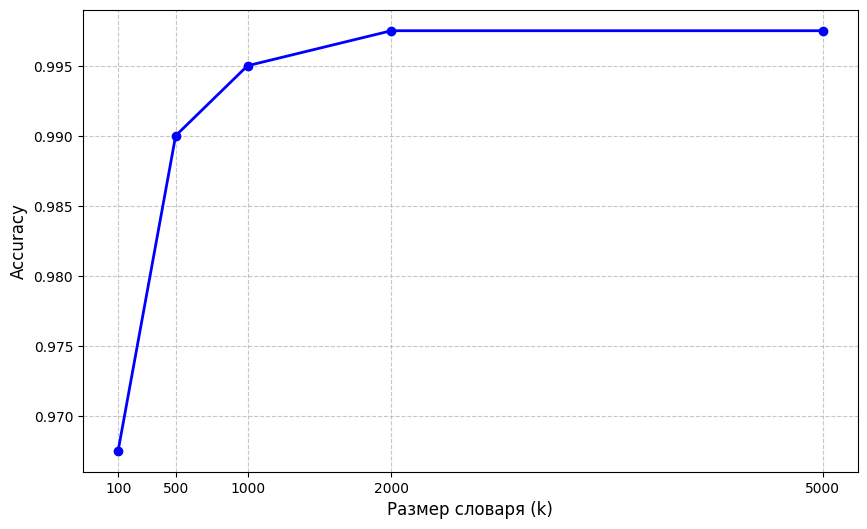

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

train_texts, val_texts, y_train, y_val = train_test_split(
    df['processed_text'], 
    df['topic'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df['topic']
)

k_values = [100, 500, 1000, 2000, 5000]
accuracies_svm = []

print('Начало исследования влияние размера на точность модели SVM:')

for k in k_values:
    print(f'Построение словаря из {k} слов...')
    vectorizer = TfidfVectorizer(max_features=k)
    vectorizer.fit(train_texts)#обучаем на первой части для словаря
    
    X_train_k = vectorizer.transform(train_texts)
    X_val_k = vectorizer.transform(val_texts)
    
    svm_model_k = LinearSVC(random_state=42, max_iter=10000)
    svm_model_k.fit(X_train_k, y_train)
    #точность модели на валидационной выборке
    y_pred_k = svm_model_k.predict(X_val_k)
    acc_k = accuracy_score(y_val, y_pred_k)
    accuracies_svm.append(acc_k)
    
    print(f'Размер словаря: {k}, Точность SVM: {acc_k:.4f}')

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies_svm, marker='o', linestyle='-', color='b', linewidth=2, label='SVM Accuracy')
plt.xlabel('Размер словаря (k)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(k_values)
plt.show()

In [ ]:
'''
Темы «Культура» и «Экономика» имеют настолько разный набор ключевых слов,
что модели достаточно знать всего сотню слов 
чтобы безошибочно определять тему в 96% случае


Чем больше слов мы добавляем в словарь, тем больше становится контекст 
и модель может лучше различать темы, 
особенно если тексты содержат более сложные и разнообразные слова.

2000 слов - это уже достаточно большой словарь, 
который может покрывать широкий спектр терминов и выражений,
но при этом не слишком разреженный, что может помочь модели лучше обобщать
и различать темы.
'''

**Задание 4.** Реализуйте два способа поиска новостных текстов по текстовому запросу, задаваемому пользователем.

**Первый способ** заключается в векторизации текстов и запроса по tf-idf в одном векторном пространстве и вычислении меры сходства вектора запроса и каждого из векторов текстов, используя косинусную меру близости (например, можно использовать [функцию](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html)).

**Второй способ** заключается в векторизации текстов в векторном пространстве, формируемом на основе слов запроса по методу `tf-idf`, и вычислении значений релевантности для текстов как суммы `tf-idf`-весов для каждого из текстов.

Проведите ручное тестирование и сделайте выводы о качестве способов.

In [10]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def preprocess_query(query):
    lemmas = lemmatize_text(query)
    return ' '.join(lemmas)

# вторая часть датасета
search_corpus = df['processed_text'].tolist()
# необработанные тексты для сравнения
original_texts = df['text'].tolist() if 'text' in df.columns else search_corpus

In [11]:
def search_engine(user_query, top_n=3):
    proc_query = preprocess_query(user_query)
    print(f"Запрос после обработки: {proc_query}\n")

    # косинусное сходство ---
    X_corpus = vectorizer.transform(search_corpus)
    X_query = vectorizer.transform([proc_query])
    
    cos_sim = cosine_similarity(X_query, X_corpus).flatten()
    indices1 = cos_sim.argsort()[-top_n:][::-1]
    
    # сумма весов TF-IDF по словам запроса
    #новый векторизатор, где словарь состоит ТОЛЬКО из слов запроса
    query_words = list(set(proc_query.split()))
    if not query_words:
        return "Пустой запрос"
        
    #обучаем его на всем корпусе, но фиксируем словарь словами запроса
    vec_simple = TfidfVectorizer(vocabulary=query_words)
    X_query_space = vec_simple.fit_transform(search_corpus)
    
    # релевантность = сумма весов по строке
    relevance_scores = np.asarray(X_query_space.sum(axis=1)).flatten()
    indices2 = relevance_scores.argsort()[-top_n:][::-1]

    print("Используем косинусное сходство:")
    for i in indices1:
        print(f"Score: {cos_sim[i]:.4f} | {original_texts[i][:150]}...")
        
    print("\nИспользуем сумму весов TF-IDF по словам запроса:")
    for i in indices2:
        print(f"Score: {relevance_scores[i]:.4f} | {original_texts[i][:150]}...")



In [12]:
print("Тестирование поисковой системы:")
query= ["банк инвестиции фондовый рынок",
        "кино актер режиссер премия",
        "финансирование театров и выставок",
        "футбол гол тренер матч"]
for q in query:
    print(f"\nЗапрос: {q}")
    search_engine(q)

Тестирование поисковой системы:

Запрос: банк инвестиции фондовый рынок
Запрос после обработки: банк инвестиция фондовый рынок

Используем косинусное сходство:
Score: 0.2571 | Глава отдела макроэкономического прогнозирования датского инвестиционного Saxo Bank Кристофер Дембик обнаружил «тормоз» у экономики США — им стал рыно...
Score: 0.2187 | Американские фондовые рынки рухнули на фоне негатива, вызванного торговой войной и очередными заявлениями президента США Дональда Трампа. Об этом свид...
Score: 0.2102 | Российские банки показывают самую низкую кредитоспособность среди стран БРИКС, следует из отчета международного рейтингового агентства Moody's. Лучшую...

Используем сумму весов TF-IDF по словам запроса:
Score: 1.7059 | 11 октября 2018 года, представители Федеральной корпорации по развитию малого и среднего предпринимательства (Корпорация МСП) приняли участие в Междун...
Score: 1.6695 | 10-летний Дэвид и 12-летний Зак Тэннеры из американского Хьюстона купили квартиру в строящемся

In [ ]:
'''
Косинусное сходство умнее.

Косинусное сходство сравнивает запрос со всем «профилем» текста.
Если текст про экономику, то даже если в нем нет слова «фондовый», 
другие экономические слова в векторе TF-IDF «притянут» этот текст к запросу.
Сумма весов часто выдает тексты, которые лишь косвенно касаются темы.

Косинусное сходство учитывает весь контекст текста,
   а сумма весов может быть более чувствительной к наличию отдельных слов, 
   что иногда приводит к менее релевантным результатам.
'''